# The HiggsML Challenge


For the last coding assignment, you'll need to implement a neural network. We'll look at a relatively simple binary classification problem. 

### Tasks:

1. Remember: scale your data appropriately

2. Decide on a testing strategy (a simple test/train split? a CV strategy? set a test set aside to be looked at at the very end?)

2. Decide your optimization metric.

3. Write down your neural network. I would start from a fully connected, multi-layer perceptron. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning. 

3. Optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best.  Do your best now to optimize the network architecture. Be creative!

4. Report on the perfomance of the network on the test set; report other metrics that have not been optimized.


### A few tips:

- In scikit-learn, remember that you can utilize all availables cores on your machine with `n_jobs=-1`. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
- If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
- On cross validation, for scikit learn we've seen how to use `GridSearchCV` already. For Tensorflow, there's a really cool tool called [Tensorboard](https://www.tensorflow.org/tensorboard)

### Datasets:

Branching out of astrophysics, let's mess around with a dataset of simulated but very realistic events from the ATLAS particle collider at CERN.
- Data are at `solutions/higgs.tar.gz` (you need to uncompress with `tar -czvf`)
- There are $N_{\rm samples} = 2.5\times 10^5$ entries with $N_{\rm features}=30$ measured features each.
- The label is `s` (source) vs `b` (background).
- For some background on both the physics and the dataset see [this document](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf); includes a description of the   features and how data have been padded (-999) for missing values.
- This dataset was part of a major challenge that run on Kaggle in 2014: https://higgsml.ijclab.in2p3.fr/ 

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load CSV
df = pd.read_csv("higgs.csv")  # You might need to extract `higgs.tar.gz` first

# Drop non-feature columns
event_ids = df['EventId']
weights = df['Weight']
labels = df['Label'].map({'s': 1, 'b': 0})
X = df.drop(['EventId', 'Weight', 'Label'], axis=1)

# Replace missing values (-999.0) with NaN, then impute
X.replace(-999.0, np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

print(X.shape)

(250000, 30)


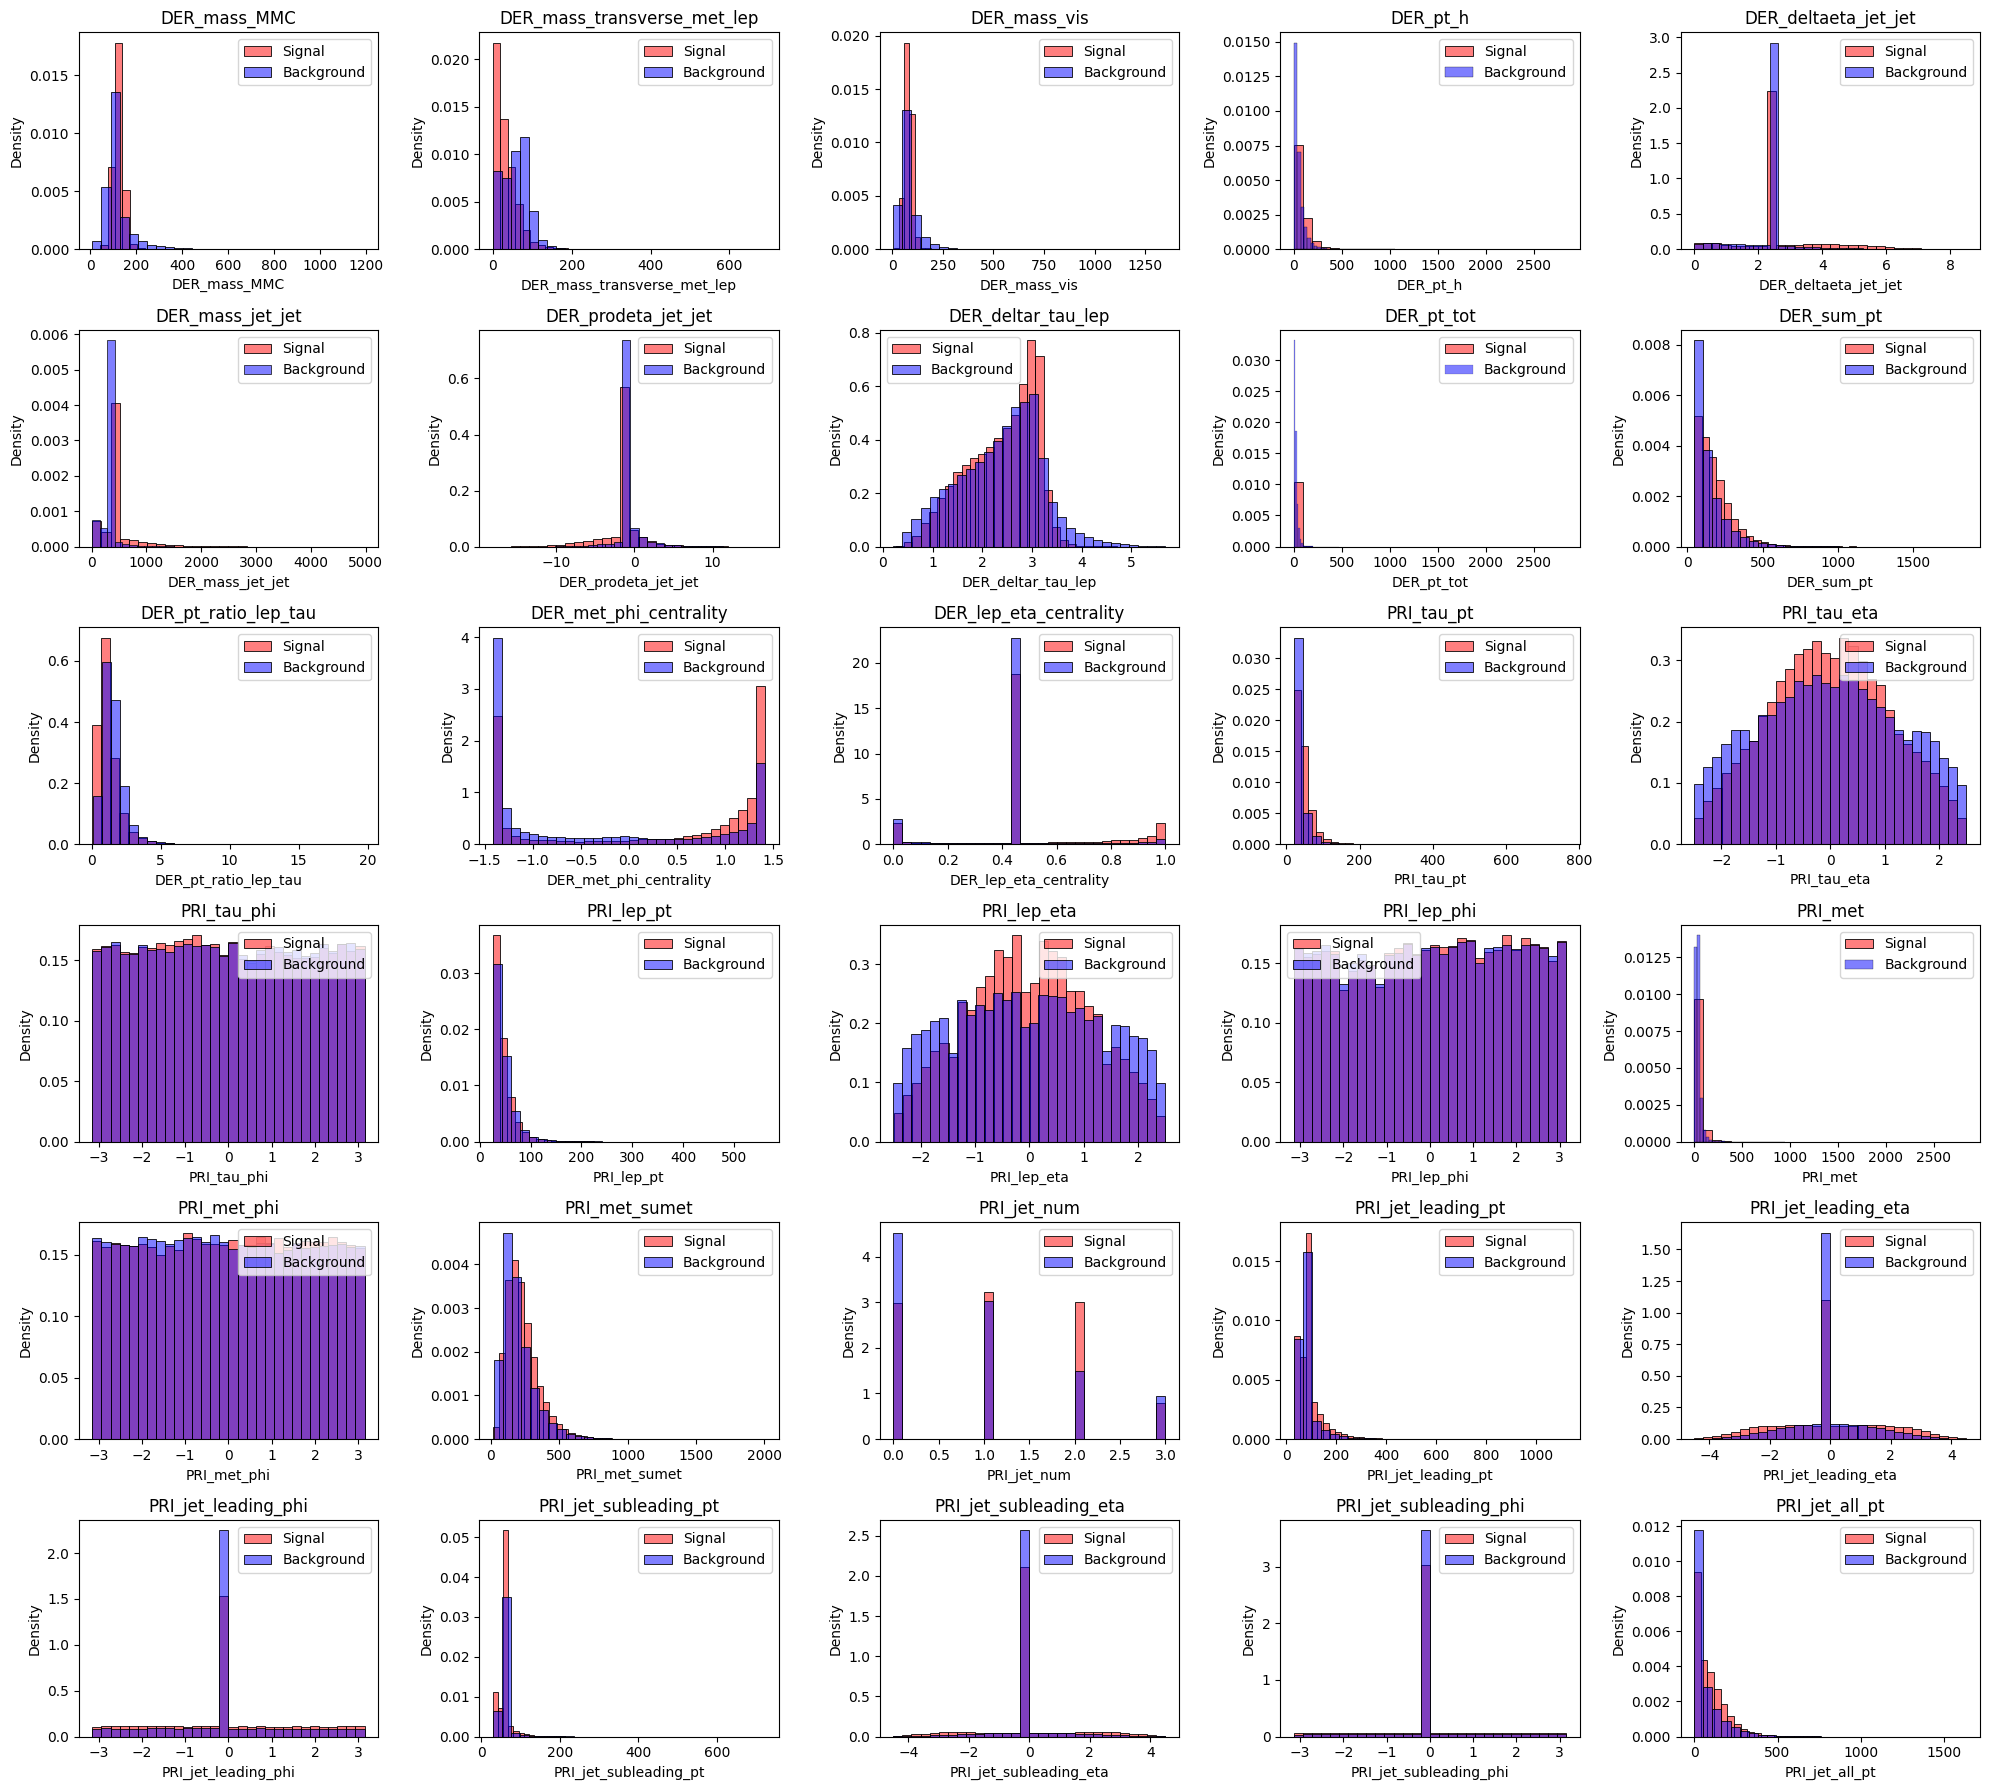

In [38]:
max_features = 30
n_cols = 5

features = X.columns[:max_features]  # Limit to first few for clarity
n_rows = int(np.ceil(len(features) / n_cols))
plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(X[col][labels == 1], color='r', label='Signal', stat='density', bins=30, alpha=0.5)
    sns.histplot(X[col][labels == 0], color='b', label='Background', stat='density', bins=30, alpha=0.5)
    plt.title(col)
    plt.legend()

plt.show()

We can see that the most important feature is DER_mass_tranverse_met_lep.

In [ ]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, labels, weights, test_size=0.2, stratify=labels, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [40]:
import tensorflow as tf
from tensorflow import keras
from keras_tuner import HyperModel
from keras_tuner.tuners import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters

def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train.shape[1],)))

    # Tune number of layers
    for i in range(hp.Int('num_layers', 1, 4)):
        model.add(keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
            activation='relu'))
        # Tune dropout rate
        model.add(keras.layers.Dropout(rate=hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))
    
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # Tune optimizer learning rate
    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    optimizer = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model


In [41]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    build_model,
    objective='val_auc',  # maximize validation AUC
    max_trials=20,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='higgsml_keras'
)

# Early stopping to speed up search
early_stop = keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)

tuner.search(X_train, y_train, epochs=30, validation_split=0.2, callbacks=[early_stop], batch_size=1024)


Trial 20 Complete [00h 01m 31s]
val_auc: 0.904884397983551

Best val_auc So Far: 0.9092255234718323
Total elapsed time: 00h 32m 25s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]

# Train best model on full training set with early stopping
history = best_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=1024,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50


C:\Users\emmag\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.8410 - auc: 0.9084 - loss: 0.3590 - val_accuracy: 0.8434 - val_auc: 0.9092 - val_loss: 0.3555
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8421 - auc: 0.9107 - loss: 0.3548 - val_accuracy: 0.8431 - val_auc: 0.9090 - val_loss: 0.3563
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8418 - auc: 0.9096 - loss: 0.3569 - val_accuracy: 0.8428 - val_auc: 0.9093 - val_loss: 0.3563
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8416 - auc: 0.9105 - loss: 0.3550 - val_accuracy: 0.8440 - val_auc: 0.9098 - val_loss: 0.3544
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8420 - auc: 0.9111 - loss: 0.3538 - val_accuracy: 0.8433 - val_auc: 0.9097 - val_loss: 0.3555
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8430 - auc: 0.9121 - loss: 0.3521 - val_accuracy: 0.8439 - val_auc: 0.9094 - val_loss: 0.3552
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27

In [43]:
results = best_model.evaluate(X_test, y_test)
print("Test loss, accuracy, AUC:", results)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8413 - auc: 0.9094 - loss: 0.3568
Test loss, accuracy, AUC: [0.3556486666202545, 0.8407800197601318, 0.9103626608848572]


In [ ]:
def ams_score(s, b, b_reg=10):
    from math import sqrt, log
    
    # -----
    # s: estimated total weight of true signal events selected by your model (true positives)
    # b: estimated total weight of background events wrongly selected as signal (false positives)
    # b_reg: regularization term added to b to prevent numerical instability (e.g., log(0)); usually set to 10
    # -----
    
    # Compute the AMS score using the formula:
    # AMS = sqrt( 2 * [ (s + b + b_reg) * log(1 + s / (b + b_reg)) - s ] )
    #
    # This is a smoothed and regularized approximation of the discovery significance.
    # The expression inside the log() is > 1 if s > 0, leading to a positive contribution.
    
    radicand = 2 * ((s + b + b_reg) * log(1.0 + s / (b + b_reg)) - s)
    return sqrt(radicand) if radicand > 0 else 0



y_pred_proba = best_model.predict(X_test).ravel()
best_ams = 0
best_threshold = 0.5

for threshold in np.linspace(0, 1, 100):  # try thresholds from 0 to 1
    selected = y_pred_proba > threshold
    s = w_test[(y_test == 1) & selected].sum() # true poitive
    b = w_test[(y_test == 0) & selected].sum() # false positive
    #print("s: ", s, "\n b: ", b, "\n")
    ams = ams_score(s, b)
    if ams > best_ams:
        best_ams = ams
        best_threshold = threshold

print(f"\n Best AMS = {best_ams:.4f} at threshold = {best_threshold:.2f}")


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

 Best AMS = 1.5535 at threshold = 0.81


Considering that the highest AMS value at the end of the competition was 3.80581, I feel pretty bad :(
    
I'll try to improve my skills in Neural Network.
